In [1]:
# CIL optimisation algorithms and linear operators
from cil.optimisation.utilities.HybridUpdateReg import UpdateRegDiscrep, UpdateRegGCV, UpdateRegLcurve, UpdateRegReginska, UpdateRegUPRE
from cil.optimisation.operators import WaveletOperator, GradientOperator
from cil.optimisation.operators import PaddedDirichletGradientOperator
from cil.optimisation.algorithms import HybridGLSQR, GLSQR
# Third-party imports
import numpy as np
from time import time    

# CIL imports for data loading and visualisation
from cil.utilities.display import show2D

## Load Data
In this example, we utilize CIL's simulated sphere data. To accelerate computations in this notebook, we extract a 2D slice from the 3D dataset. Additionally, we select a subset of angles to create a limited-angle reconstruction scenario. We will then compare the ground truth data with a filtered back projection (FBP) reconstruction under these limited-angle conditions.

FDK recon

Input Data:
	angle: 60
	horizontal: 128

Reconstruction Volume:
	horizontal_y: 128
	horizontal_x: 128

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 8
	Filter_inplace: False



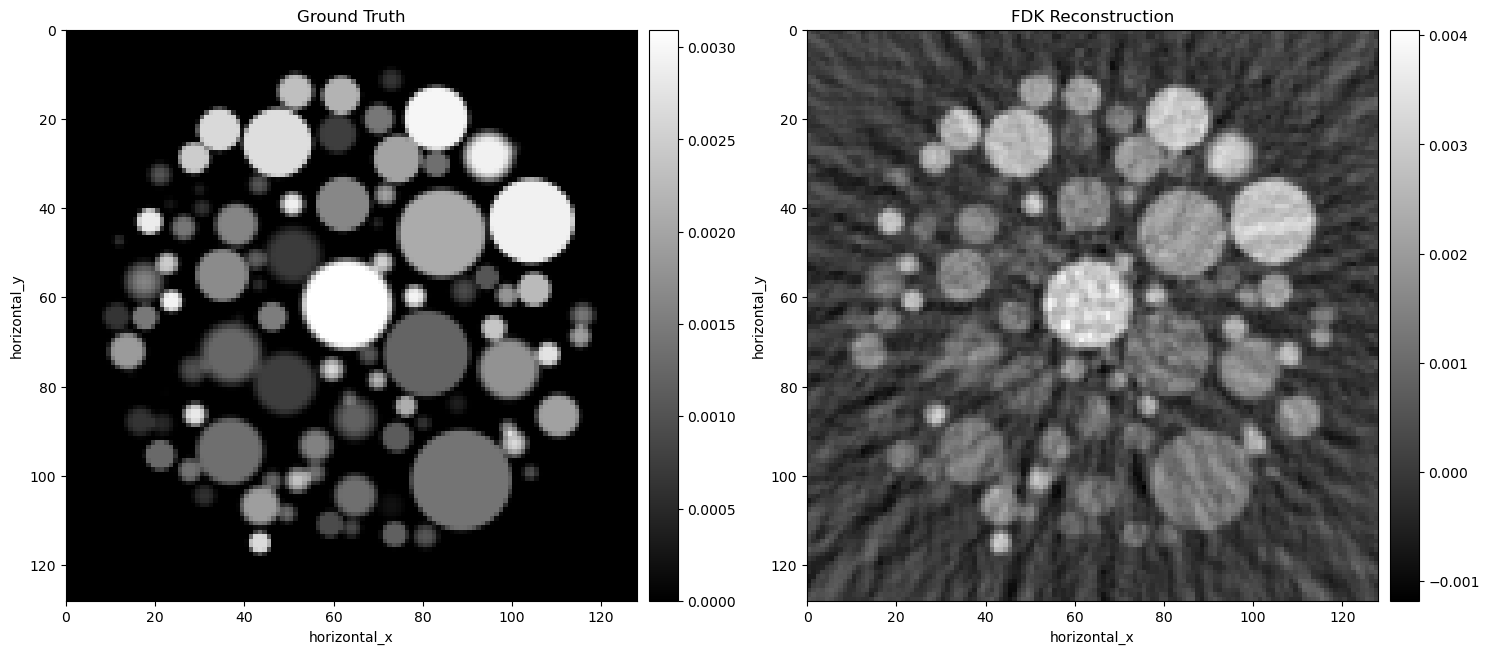

Time to compute gradient numpy:  0.0013325214385986328
Time to compute inverse gradient numpy:  0.004528045654296875
Inverse error from gradient coefficients:  9.407053e-07


/home/dnz75396/CIL/Wrappers/Python/cil/framework/data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


In [2]:
from data_loader import load_and_process_sphere

# Load data
data, A, ig, ground_truth, fdk = load_and_process_sphere(angle_step=5, single_slice=True)

# Set up Initial
initial = A.domain_geometry().allocate(0)

W = PaddedDirichletGradientOperator(
    ig,
    pad_width=1,
    backend='numpy'
)
t0 = time()
fdk_gradient=W.direct(fdk)
t1 = time()
print("Time to compute gradient numpy: ", t1-t0)

t0 = time()
recovered_fdk_gradient=W.inverse(fdk_gradient)
t1 = time()
print("Time to compute inverse gradient numpy: ", t1-t0)
diff = fdk - recovered_fdk_gradient
print("Inverse error from gradient coefficients: ", np.linalg.norm(diff.as_array())/np.linalg.norm(fdk.as_array()))


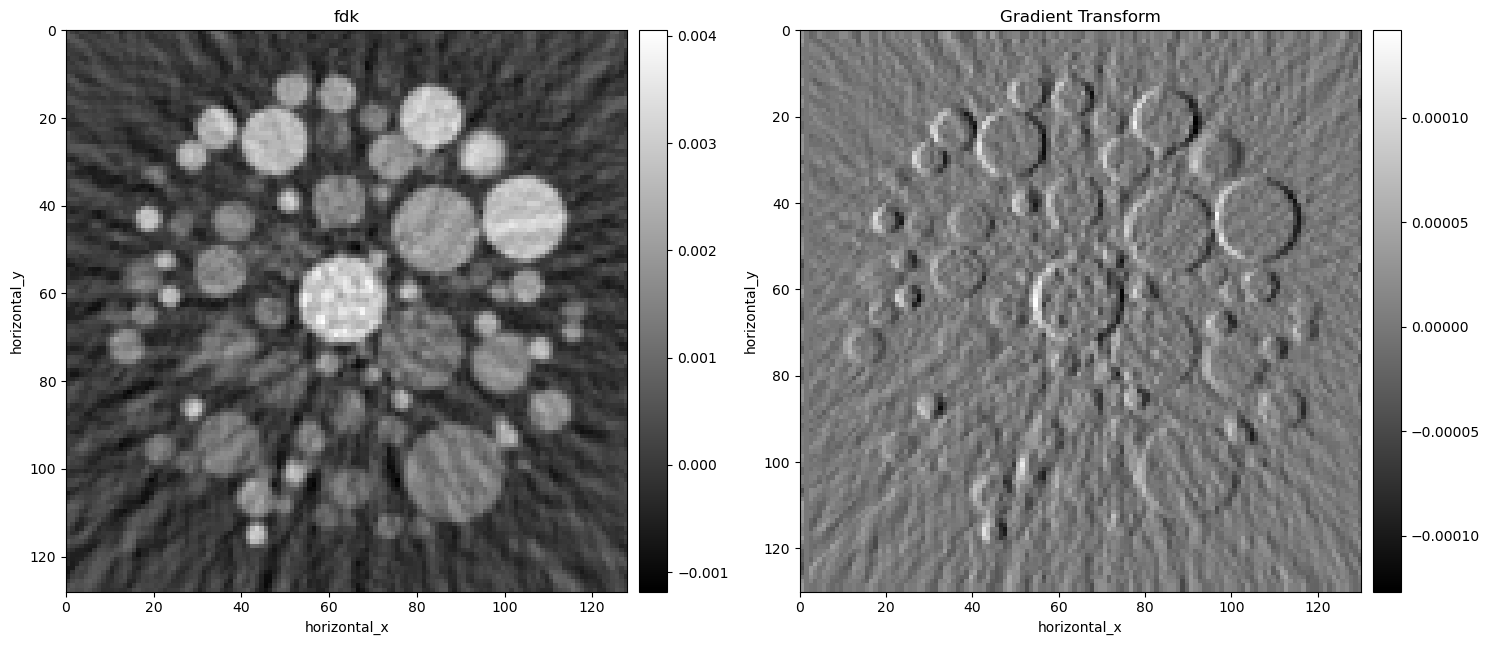

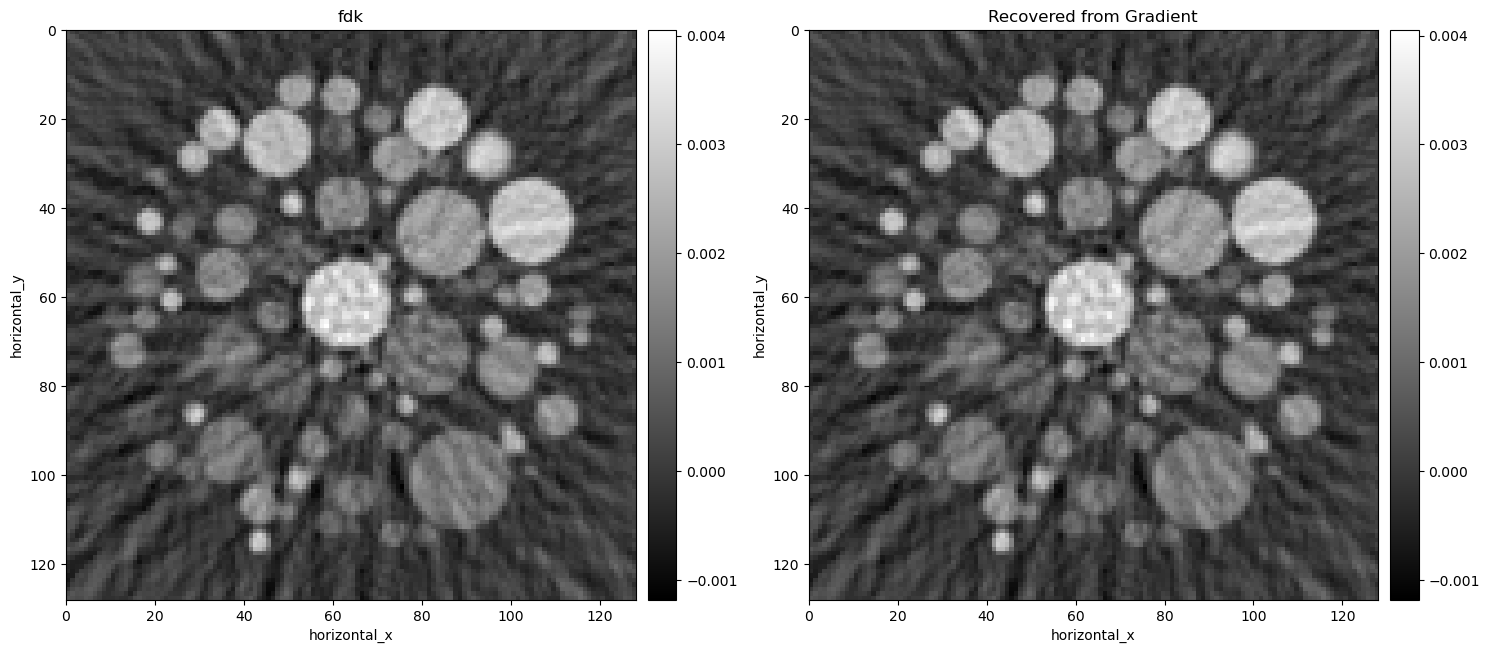

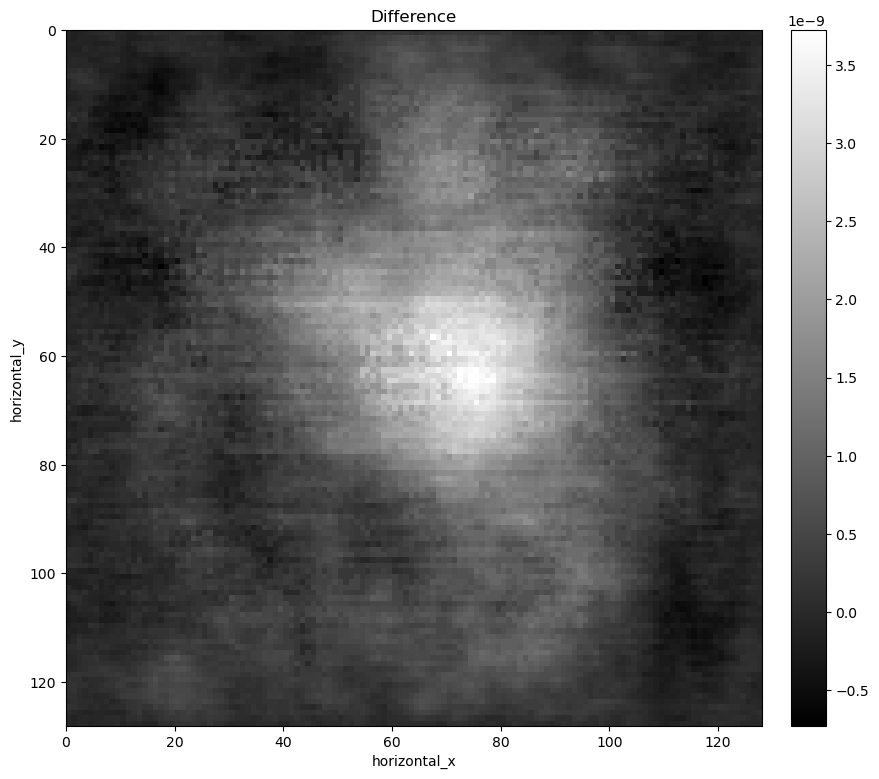

In [3]:
show2D([fdk, fdk_gradient[1]], title = ['fdk', 'Gradient Transform'], origin = 'upper', num_cols = 2)
show2D([fdk, recovered_fdk_gradient], title = ['fdk', 'Recovered from Gradient'], origin = 'upper', num_cols = 2)
show2D([diff], title = ['Difference'], origin = 'upper', num_cols = 1)

## Hybrid methods in action L1 Regularization

1. Discrepency
2. GCV
3. Weighted GCV
4. Adaptive Weighted GCV
5. Reginska
6. UPRE
7. L-curve


In [4]:
# We set a tolerance, an initial guess, and a maximum number of iterations
alpha_tol = 1e-3
maxit = 10

# Define noise level
noise_std = 0.1 * np.std(data.array) 
noiselevel = 0.05 * np.linalg.norm(data.array)
noisevariance = noise_std**2

norm_type = 'L1'

def results_and_rerun(hybridlsqr):
    print("The optimal parameter it finds is", hybridlsqr.regalpha, "in", hybridlsqr.iteration, "iterations")

    hybridlsqr.reg_rule.plot_function()
    hybridlsqr.reg_rule.plot_history()

    show2D([fdk, ground_truth, hybridlsqr.solution], 
        title = ['FDK','Ground Truth', f"{hybridlsqr.reg_rule.rule_type} \n Optimal alpha: {hybridlsqr.regalpha:.2e}"], 
        fix_range=(ground_truth.min(), ground_truth.max()*1.1),
        origin = 'upper', num_cols = 3)
    
    # Rerun GLSQR with the optimal alpha found by HybridLSQR
    inner_its = hybridlsqr.total_iterations // hybridlsqr.iteration
    lsqr = GLSQR(operator=A, data=data, initial=initial,
                            struct_operator=W, max_inner_iterations=inner_its,
                            reg_norm_type=norm_type, regalpha=hybridlsqr.regalpha)
    lsqr.run(hybridlsqr.reg_rule.iteration, verbose=True)
    show2D([fdk, ground_truth, lsqr.solution], 
        title = ['FDK','Ground Truth', f"{hybridlsqr.reg_rule.rule_type} \n Optimal alpha: {hybridlsqr.regalpha:.2e}"], 
        fix_range=(ground_truth.min(), ground_truth.max()*1.1),
        origin = 'upper', num_cols = 3)

## 1. Discrepency Rule

In [5]:
discrep_rule = UpdateRegDiscrep(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                noise_level_estimate=noiselevel)

hybridlsqrD = HybridGLSQR(operator=A, data=data, initial=initial,
                          struct_operator=W,reg_norm_type=norm_type, 
                          hybrid_reg_rule=discrep_rule)
t_start = time()
hybridlsqrD.run(maxit, verbose=True)
t_end = time()
print(f"Discrepancy rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

Discrepancy rule took 44.65440320968628 seconds.


The optimal parameter it finds is 21.78945598975071 in 10 iterations


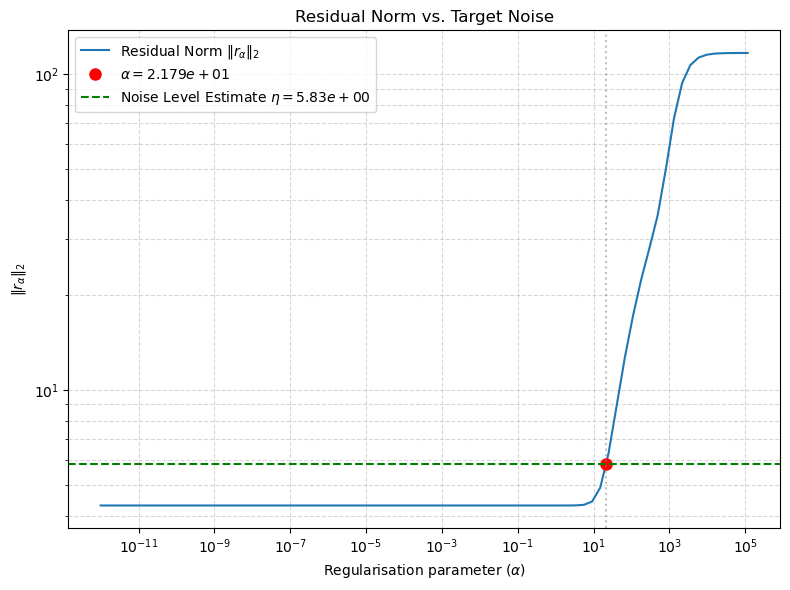

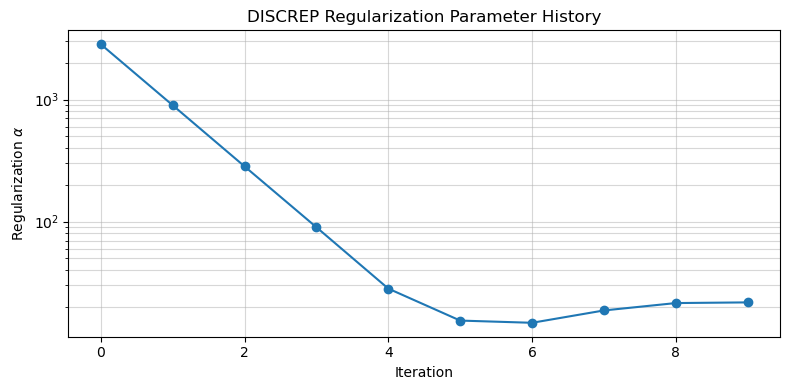

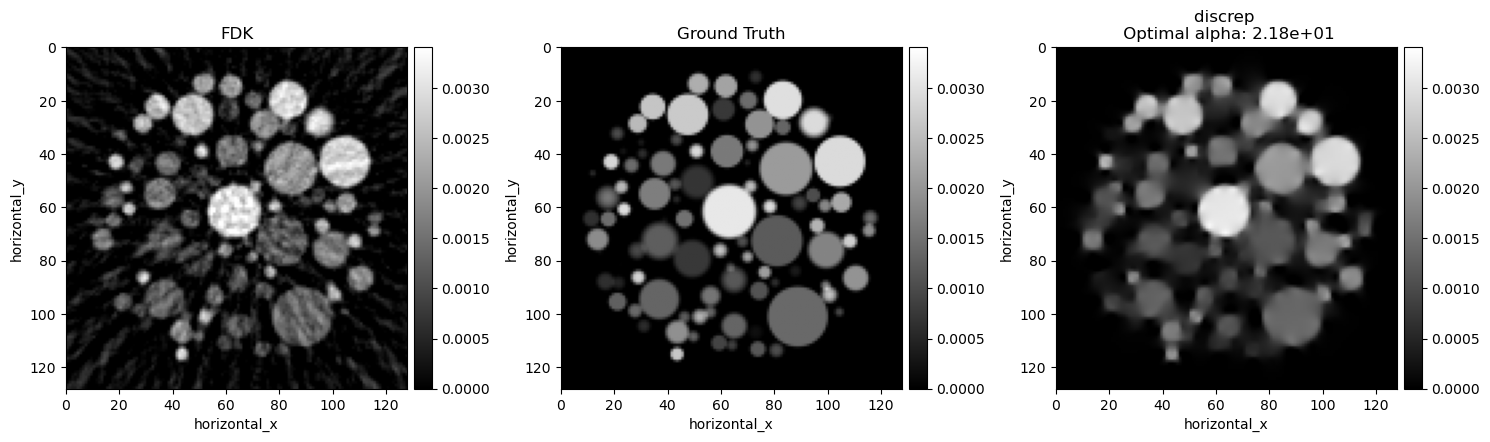

  0%|          | 0/10 [00:00<?, ?it/s]

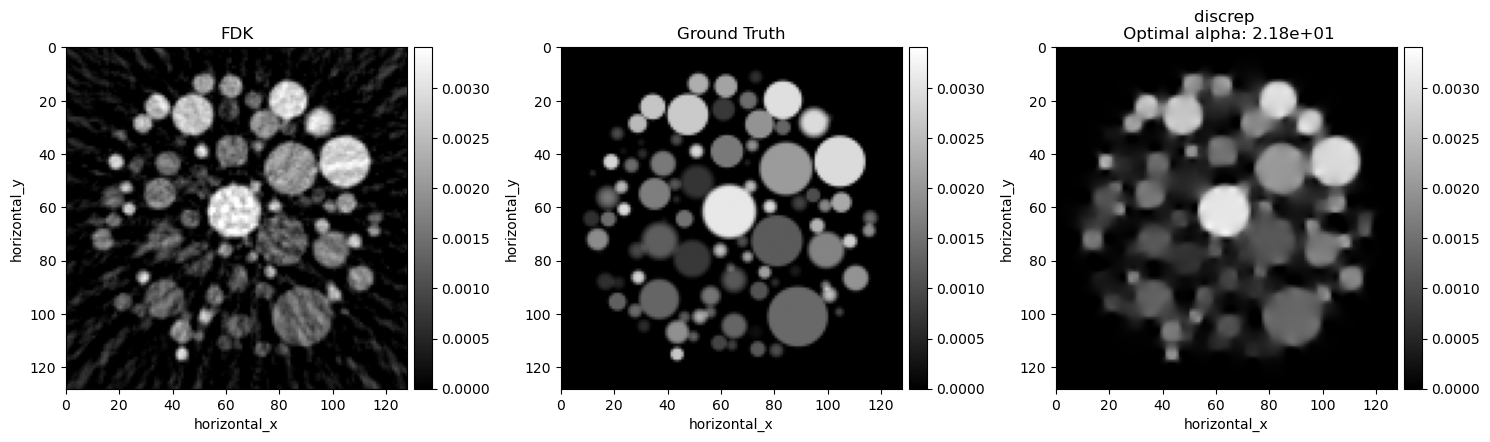

In [6]:
results_and_rerun(hybridlsqrD)

## 2. Standard GCV Rule

In [7]:
gcv_rule = UpdateRegGCV(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                adaptive_weight=False)

hybridlsqrgcv = HybridGLSQR(operator=A, data=data, initial=initial,
                           struct_operator=W, 
                         reg_norm_type=norm_type, hybrid_reg_rule=gcv_rule)
t_start = time()
hybridlsqrgcv.run(maxit, verbose=True)
t_end = time()
print(f"GCV rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

GCV rule took 6.136014461517334 seconds.


The optimal parameter it finds is 327.21123952452405 in 10 iterations


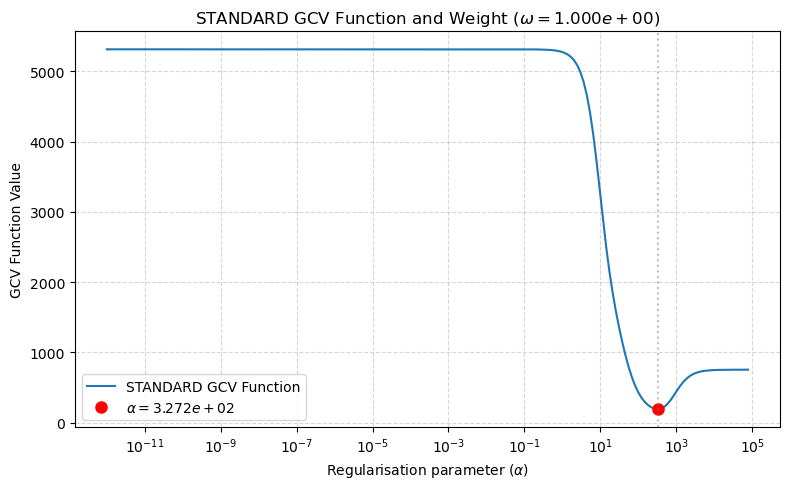

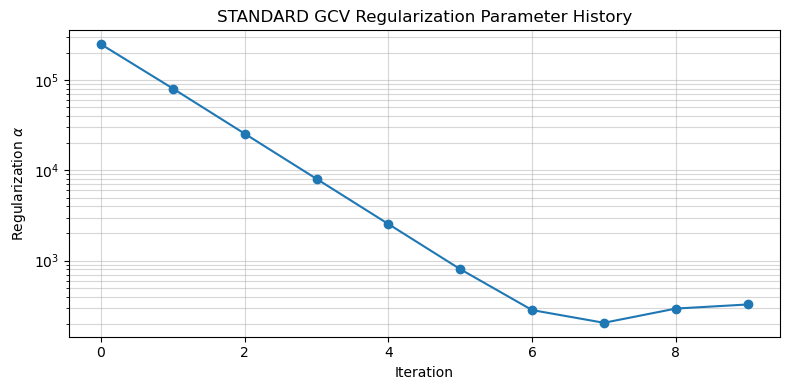

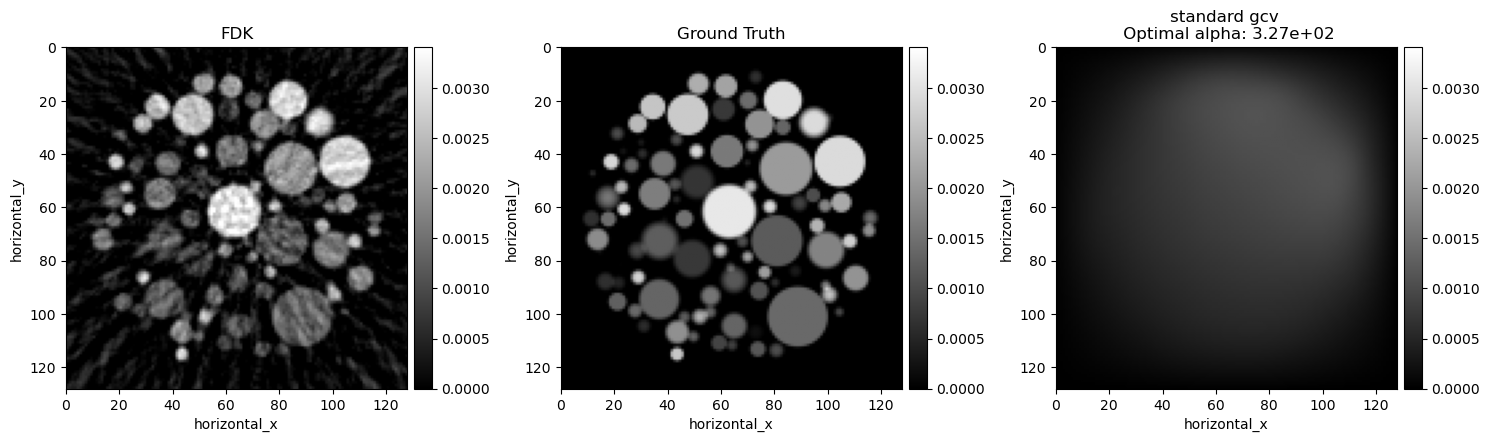

  0%|          | 0/10 [00:00<?, ?it/s]

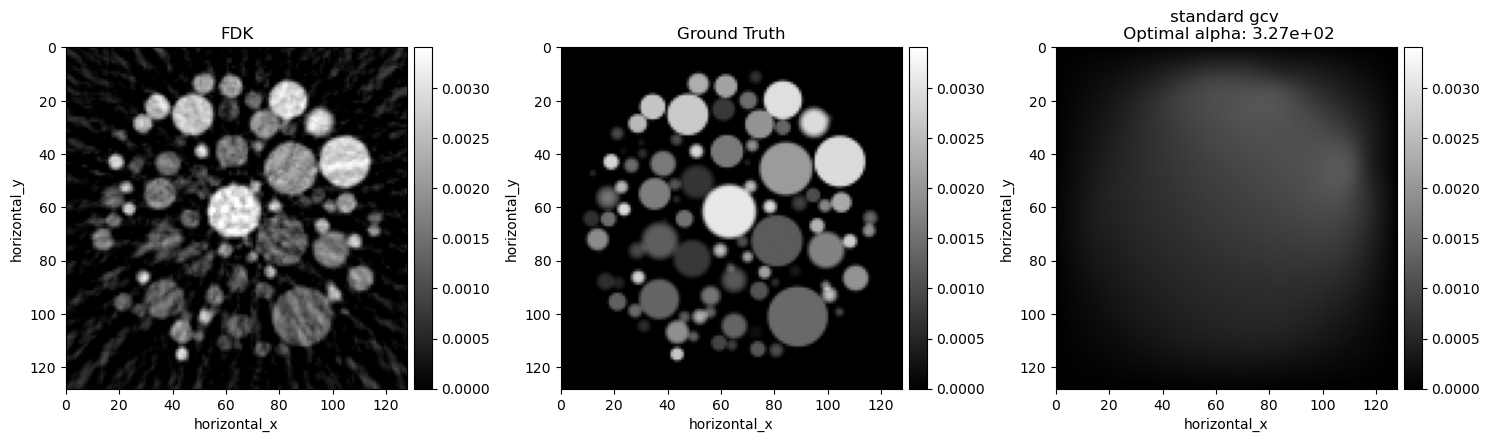

In [8]:
results_and_rerun(hybridlsqrgcv)

## 3. Weighted GCV Rule

In [9]:
wgcv_rule = UpdateRegGCV(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                gcv_weight=0.7,
                                adaptive_weight=False)

hybridlsqrwgcv = HybridGLSQR(operator=A, data=data, initial=initial, 
                            struct_operator=W, 
                         reg_norm_type=norm_type, hybrid_reg_rule=wgcv_rule)
t_start = time()
hybridlsqrwgcv.run(maxit, verbose=True)
t_end = time()
print(f"WGCV rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

WGCV rule took 5.656732797622681 seconds.


The optimal parameter it finds is 166.91531192006553 in 5 iterations


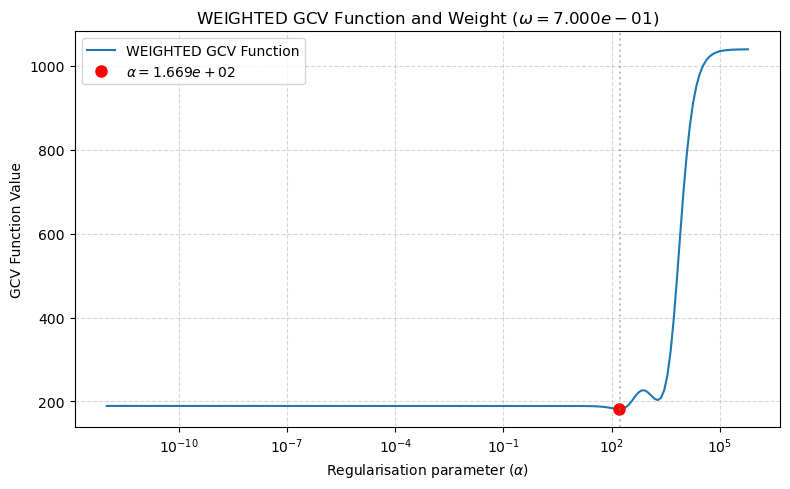

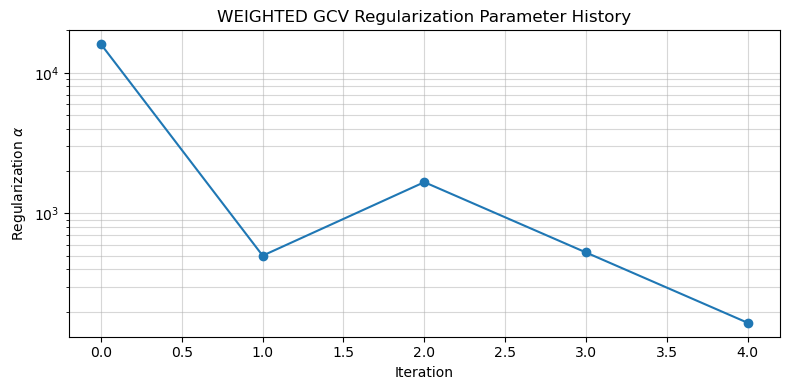

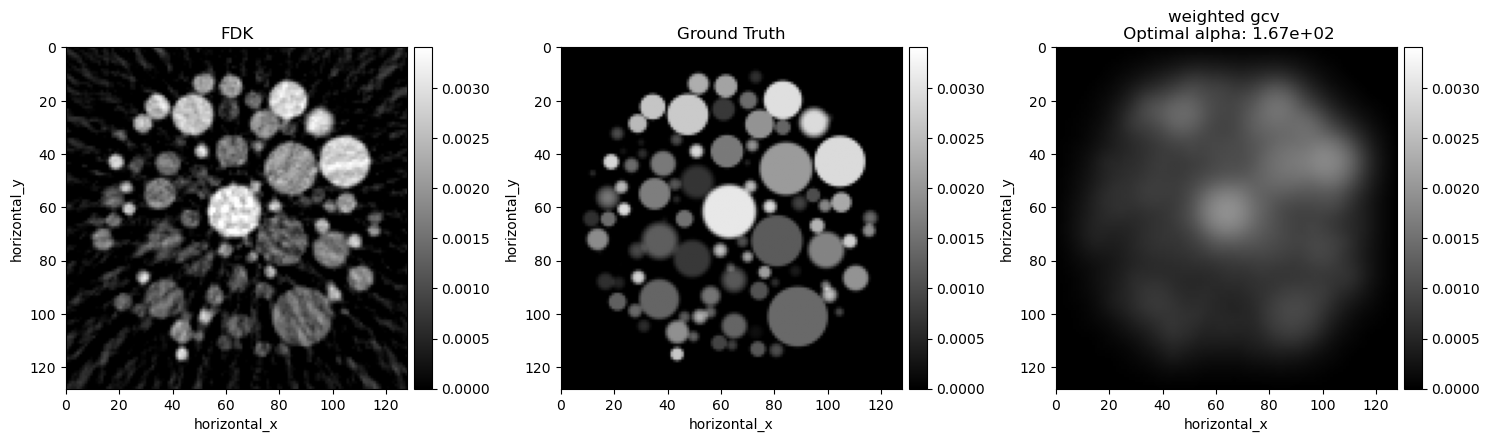

  0%|          | 0/5 [00:00<?, ?it/s]

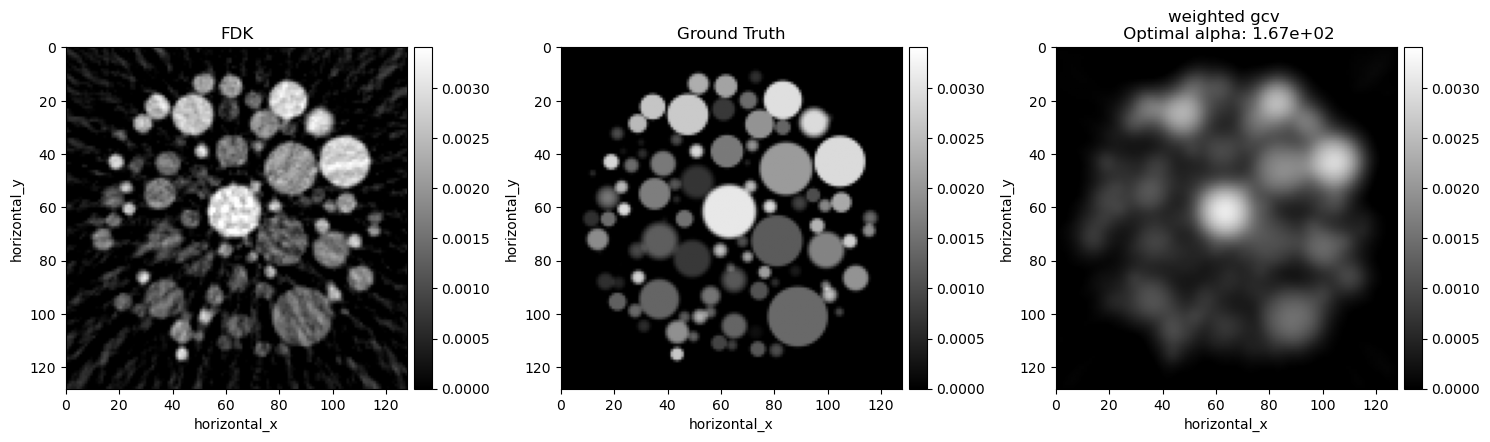

In [10]:
results_and_rerun(hybridlsqrwgcv)

## 4. Adaptive-Weighted GCV Rule

In [11]:
awgcv_rule = UpdateRegGCV(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                adaptive_weight=True)

hybridlsqrawgcv = HybridGLSQR(operator=A, data=data, initial=initial,
                              struct_operator=W, 
                         reg_norm_type=norm_type, hybrid_reg_rule=awgcv_rule)
t_start = time()
hybridlsqrawgcv.run(maxit, verbose=True)
t_end = time()
print(f"Adaptive WGCV rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

Adaptive WGCV rule took 1.772648811340332 seconds.


The optimal parameter it finds is 6795.109608917527 in 4 iterations


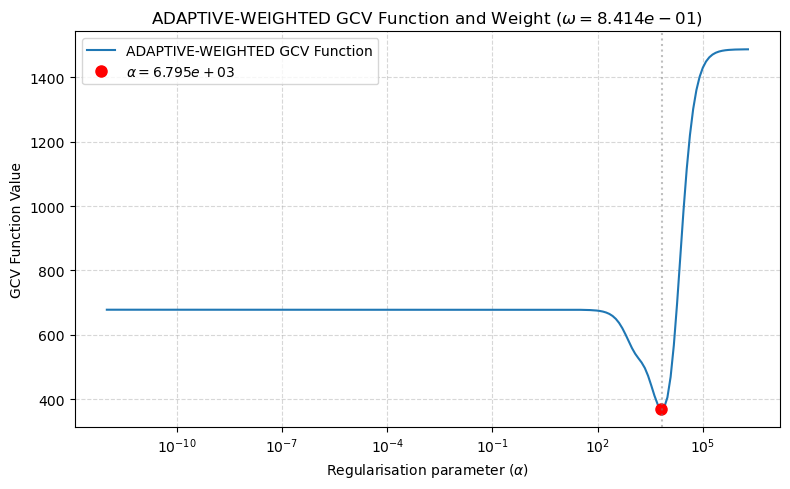

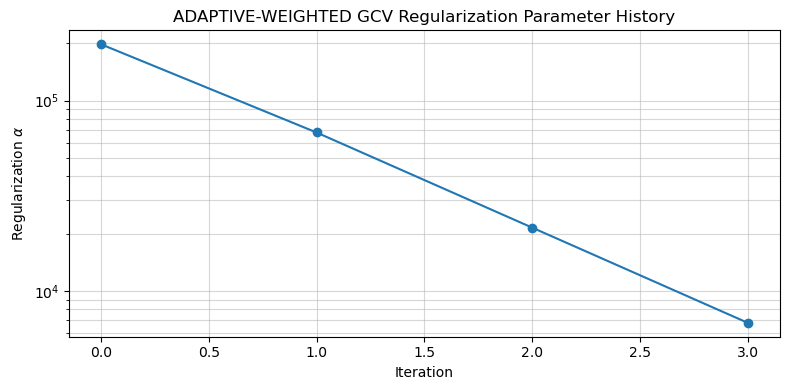

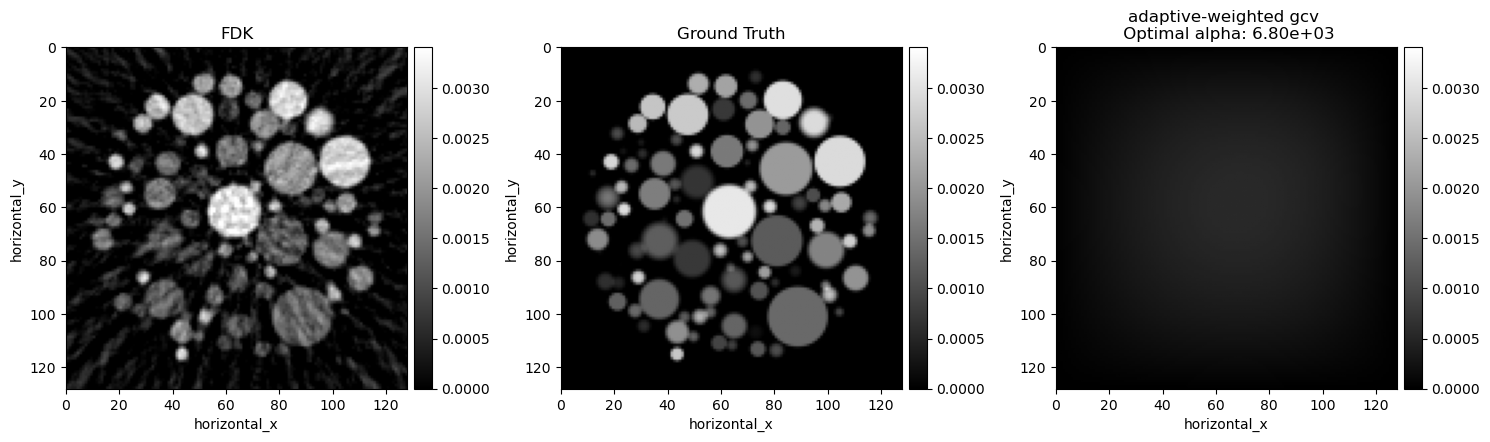

  0%|          | 0/4 [00:00<?, ?it/s]

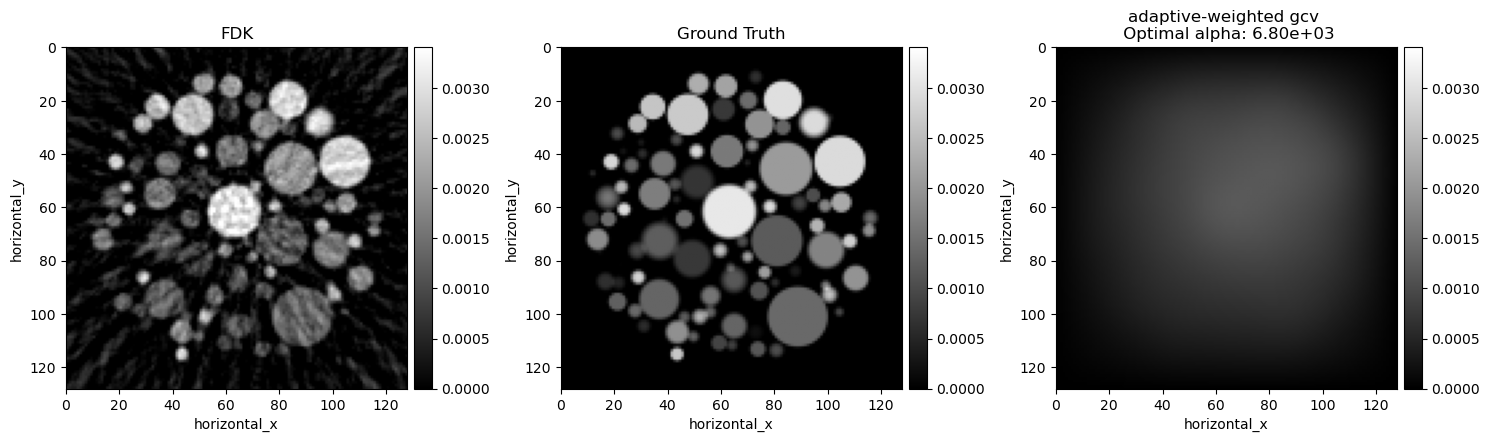

In [12]:
results_and_rerun(hybridlsqrawgcv)

## 5. Reginska Rule

In [13]:
reginska_rule = UpdateRegReginska(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol)

hybridlsqrreginska = HybridGLSQR(operator=A, data=data, initial=initial, 
                                 struct_operator=W, 
                         reg_norm_type=norm_type, hybrid_reg_rule=reginska_rule)
t_start = time()
hybridlsqrreginska.run(maxit, verbose=True)
t_end = time()
print(f"Reginska rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

Reginska rule took 4.315488815307617 seconds.


The optimal parameter it finds is 129.731168377443 in 10 iterations


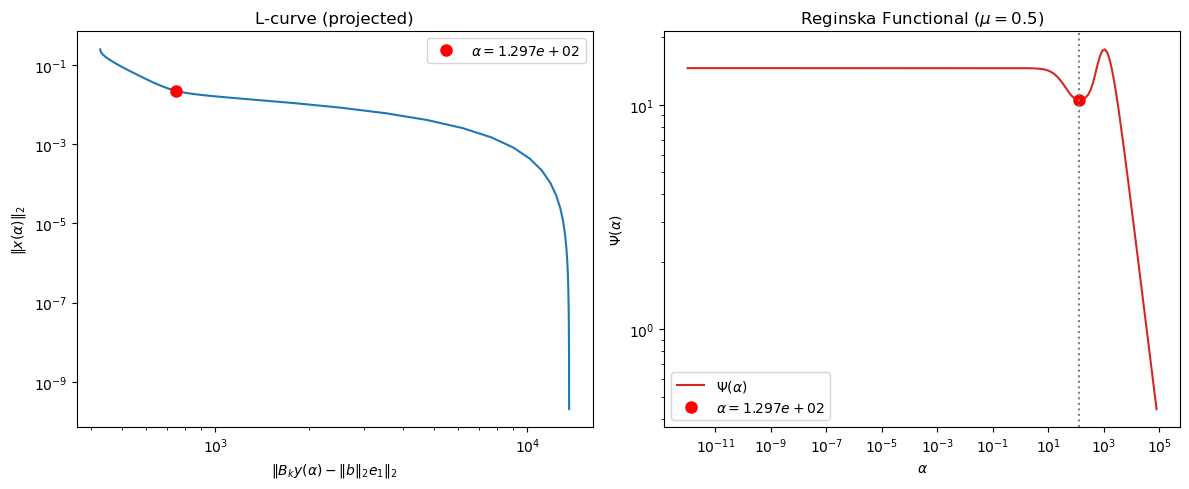

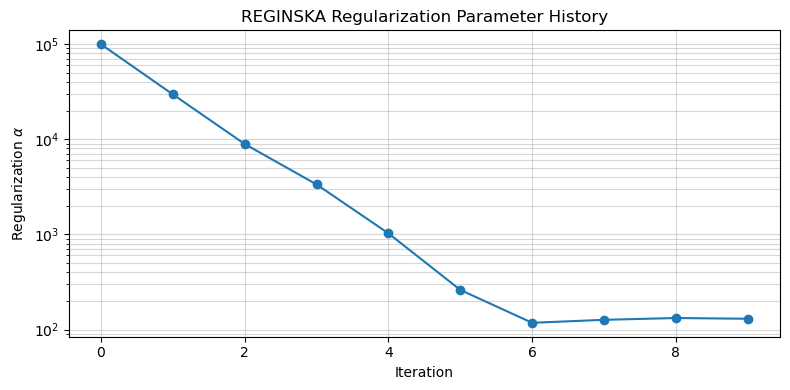

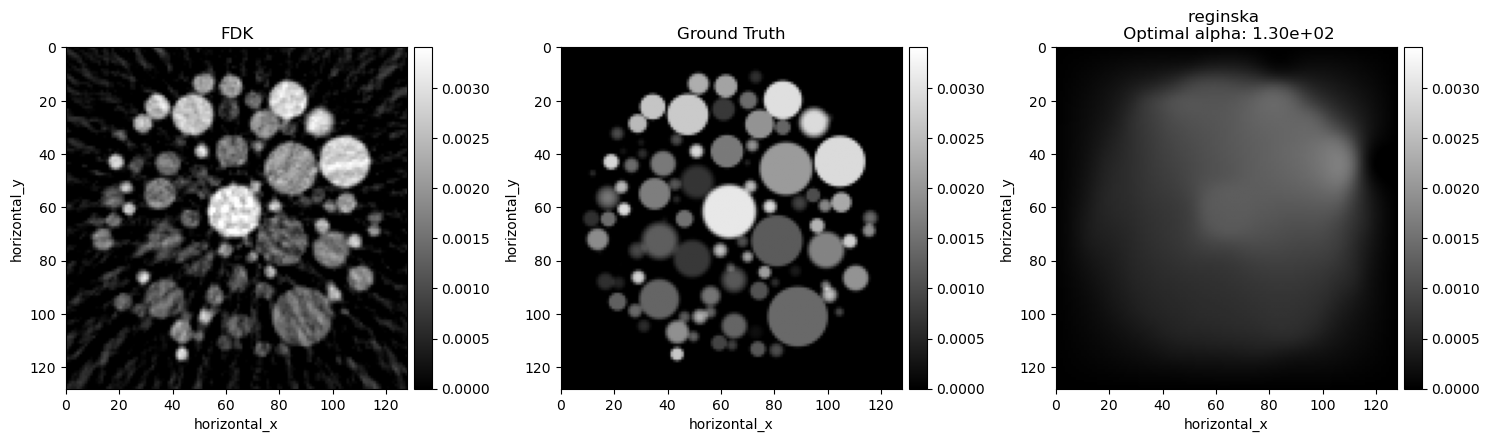

  0%|          | 0/10 [00:00<?, ?it/s]

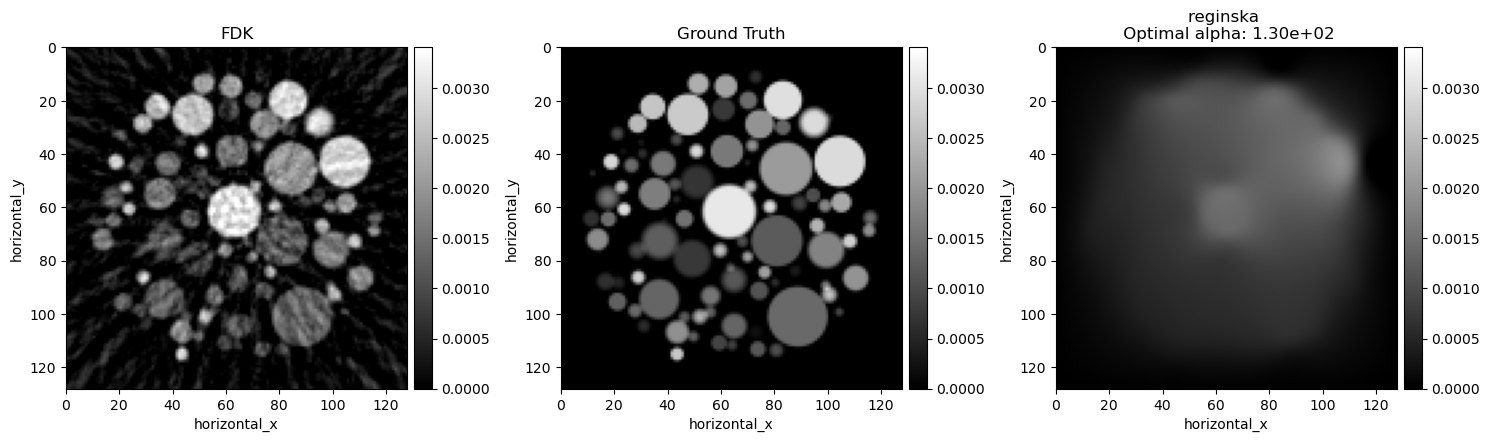

In [14]:
results_and_rerun(hybridlsqrreginska)

## 5. UPRE Rule

In [15]:
upre_rule = UpdateRegUPRE(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol,
                                noise_variance=noisevariance)

hybridlsqrupre = HybridGLSQR(operator=A, data=data, initial=initial,
                             struct_operator=W,
                         reg_norm_type=norm_type, hybrid_reg_rule=upre_rule)
t_start = time()
hybridlsqrupre.run(maxit, verbose=True)
t_end = time()
print(f"UPRE rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

UPRE rule took 4.616072416305542 seconds.


The optimal parameter it finds is 0.5207556903932139 in 10 iterations


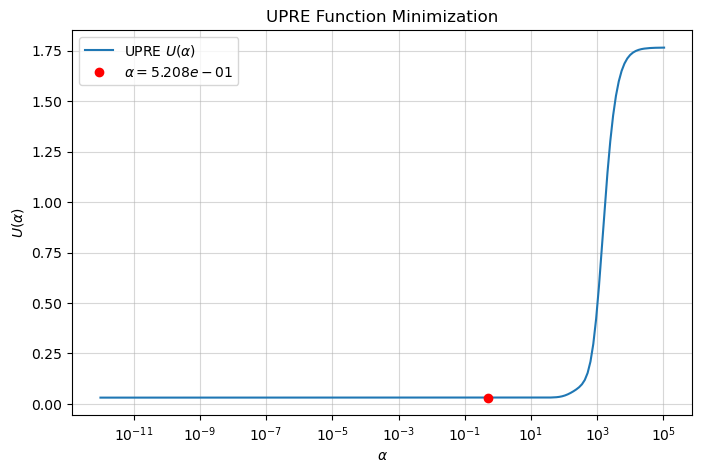

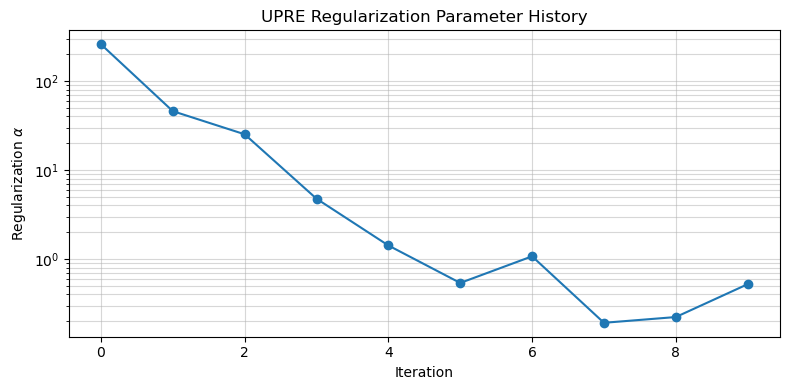

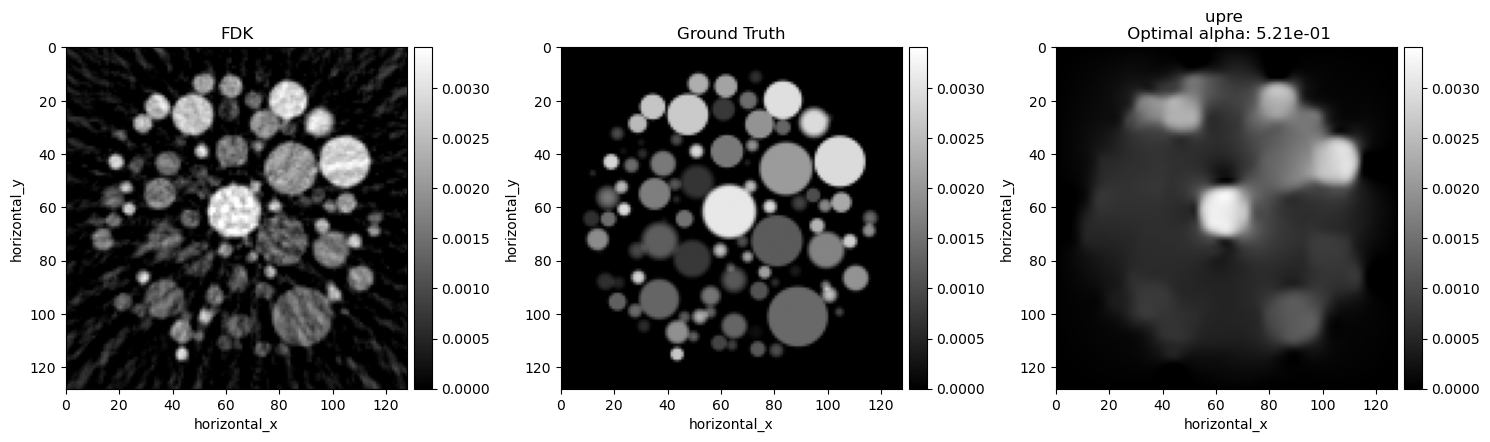

  0%|          | 0/10 [00:00<?, ?it/s]

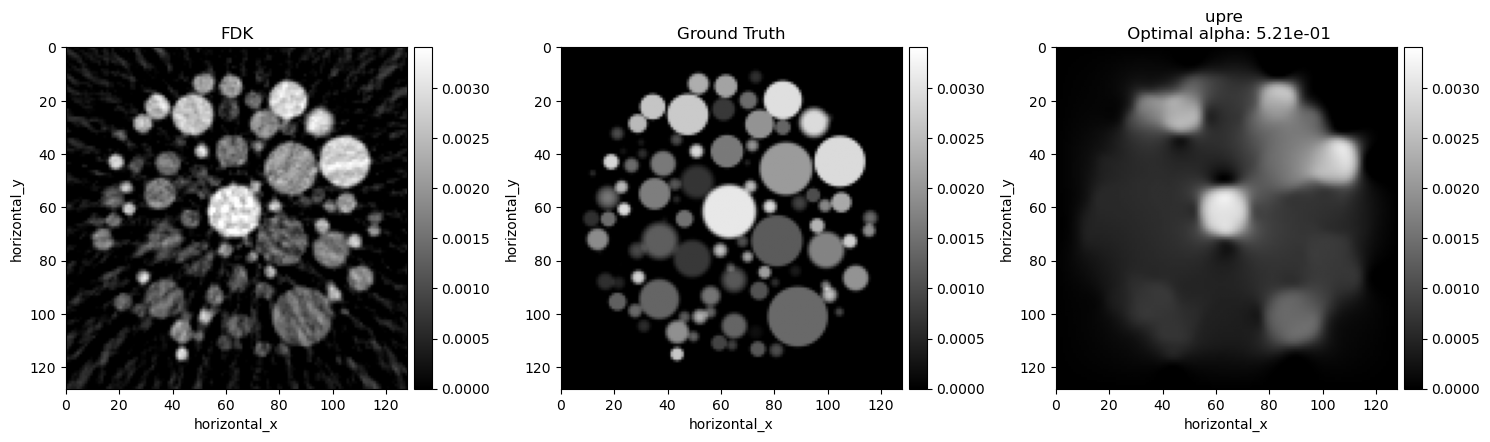

In [16]:
results_and_rerun(hybridlsqrupre)

## 7. L-curve Rule

In [17]:
lcurve_rule = UpdateRegLcurve(data_size=data.size,
                                domain_size=initial.size, 
                                tol=alpha_tol)

hybridlsqrlcurve = HybridGLSQR(operator=A, data=data, initial=initial,
                           struct_operator=W,
                         reg_norm_type=norm_type, hybrid_reg_rule=lcurve_rule)
t_start = time()
hybridlsqrlcurve.run(maxit, verbose=True)
t_end = time()
print(f"L-curve rule took {t_end - t_start} seconds.")

  0%|          | 0/10 [00:00<?, ?it/s]

L-curve rule took 50.54550290107727 seconds.


The optimal parameter it finds is 2.8783248576110854e-11 in 10 iterations


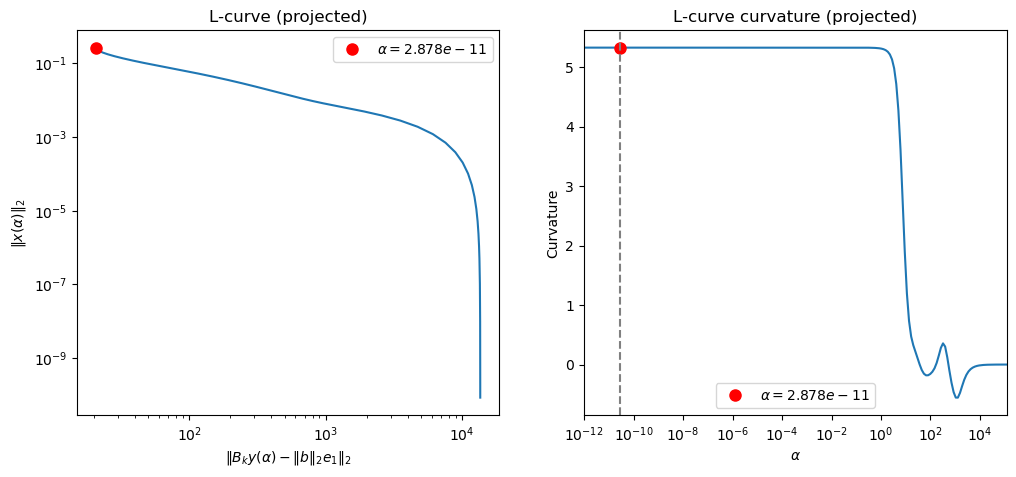

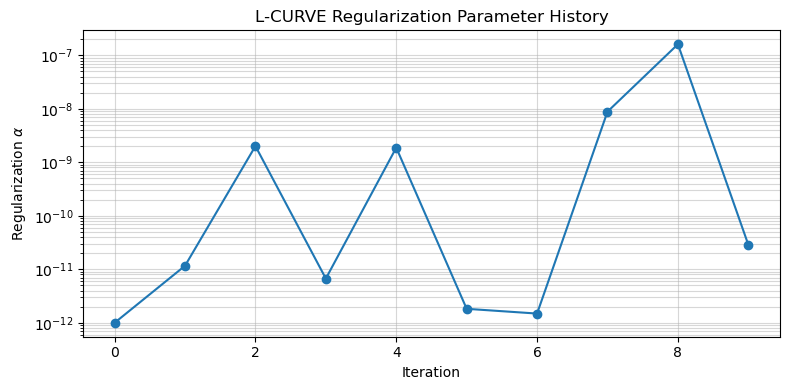

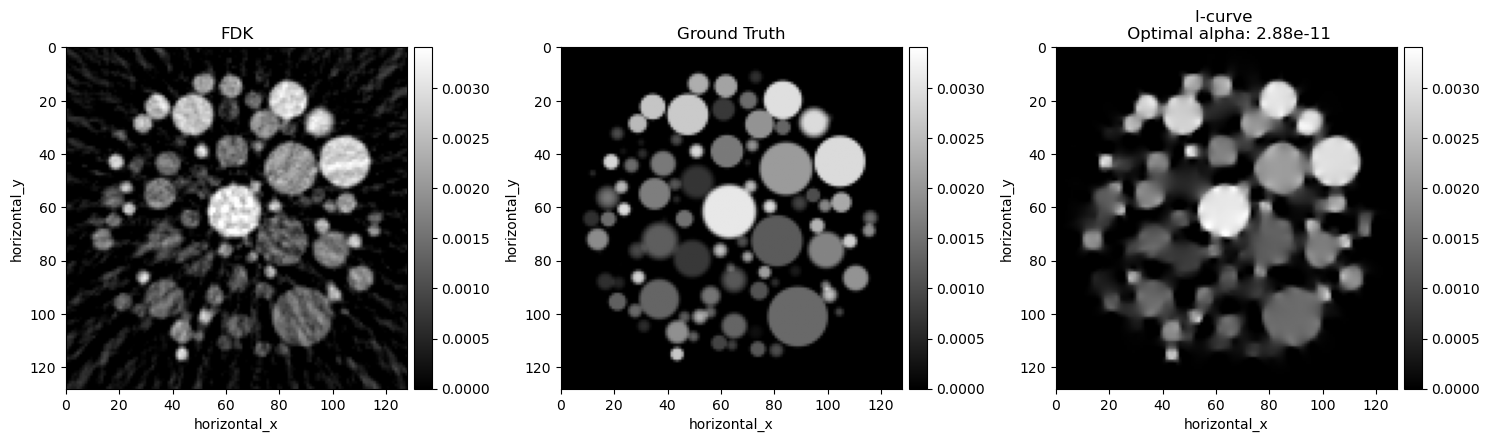

  0%|          | 0/10 [00:00<?, ?it/s]

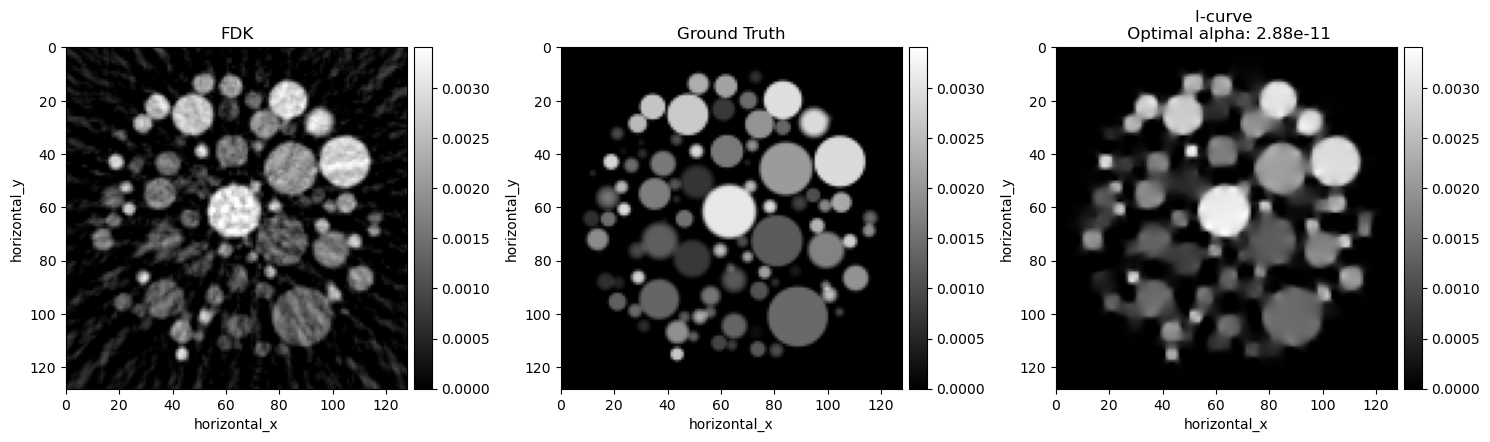

In [18]:
results_and_rerun(hybridlsqrlcurve)